In [15]:
%reload_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt
from vrAnalysis.sessions import B2Session
from vrAnalysis.helpers.plotting import save_figure
from vrAnalysis.helpers import edge2center
from vrAnalysis.database import get_database
from dimensionality_manuscript.figure_scripts.figure1 import (
    example_placefield,
    example_r2_placefield,
    example_traversal,
    stacked_raster_plot,
)
from dimensionality_manuscript.configs import PFPredQualityConfig
from dimensionality_manuscript import ResultsStore, ResultsAggregator
from dimensionality_manuscript.registry import RegistryPaths

sessiondb = get_database("vrSessions")
sessions = sessiondb.iter_sessions(imaging=True)
cfg = PFPredQualityConfig()
store = ResultsStore()
results = ResultsAggregator(cfg, store, sessions)

In [14]:
registry_paths = RegistryPaths()
figure_path = registry_paths.figure_path / "figure1"
if not figure_path.exists():
    figure_path.mkdir(parents=True, exist_ok=True)

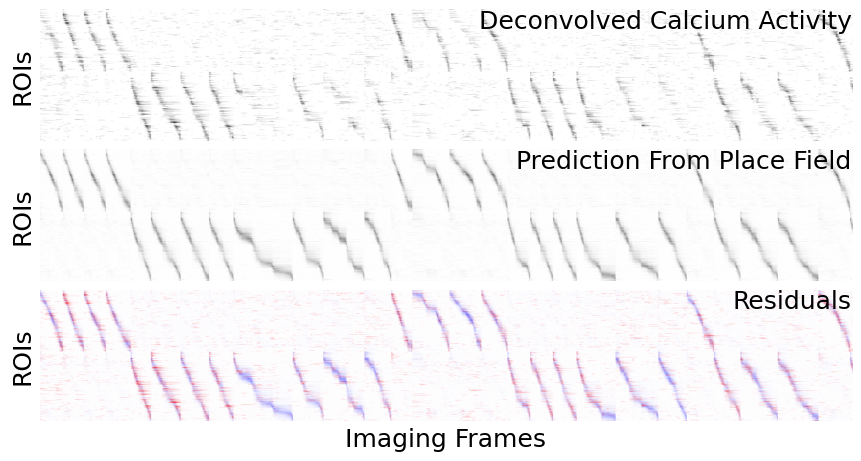

In [37]:
mouse_name = "ATL027"
date = "2023-07-27"
session_id = "701"
spks_type = "sigrebase"
session = B2Session.create(mouse_name, date, session_id, dict(spks_type=spks_type))

fig = stacked_raster_plot(session, prediction_from="placefield", figsize=(8.5, 4.5))

save_plot = True
if save_plot:
    save_figure(fig, figure_path / "stacked_raster_plot.png")

c:\Users\Andrew\AppData\Local\miniforge3\envs\vrAnalysis\Lib\site-packages\syd\support.py:162: ParameterUpdateWarning: Warning updating SelectionParameter parameter 'roi': Value 0 not in options, setting to first option (96)
  warn(ParameterUpdateWarning(parameter_name, parameter_type, message))


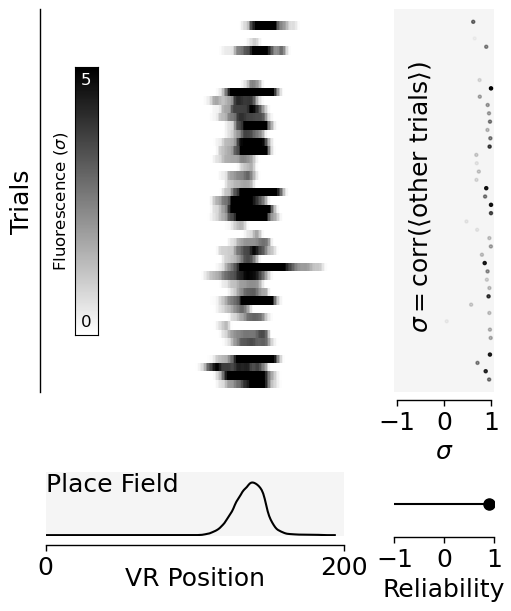

In [50]:
mouse_name = "ATL027"
date = "2023-07-27"
session_id = "701"
spks_type = "sigrebase"
idx_roi = {
    "oasis": 96,
    "sigrebase": 180,
}[spks_type]
idx_env = 0
session = B2Session.create(mouse_name, date, session_id, dict(spks_type=spks_type))

use_viewer = False
if use_viewer:
    viewer = example_placefield(session, idx_roi, idx_env, return_syd_viewer=True)
    viewer.show()

else:
    fig = example_placefield(session, idx_roi, idx_env)

    save_plot = True
    if save_plot: 
        figure_name = f"example_placefield_{mouse_name}_{date}_{session_id}_{spks_type}_{idx_roi}_{idx_env}"
        save_figure(fig, figure_path / f"{figure_name}.png")

c:\Users\Andrew\AppData\Local\miniforge3\envs\vrAnalysis\Lib\site-packages\syd\support.py:162: ParameterUpdateWarning: Warning updating SelectionParameter parameter 'roi': Value 0 not in options, setting to first option (96)
  warn(ParameterUpdateWarning(parameter_name, parameter_type, message))
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure1.py:219: RuntimeWarning: Mean of empty slice
  avg_pred_traversal = np.nanmean(pred_travs, axis=0)
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure1.py:220: RuntimeWarning: Mean of empty slice
  rms_error = np.sqrt(np.nanmean((pred_travs - traversals) ** 2, axis=0))


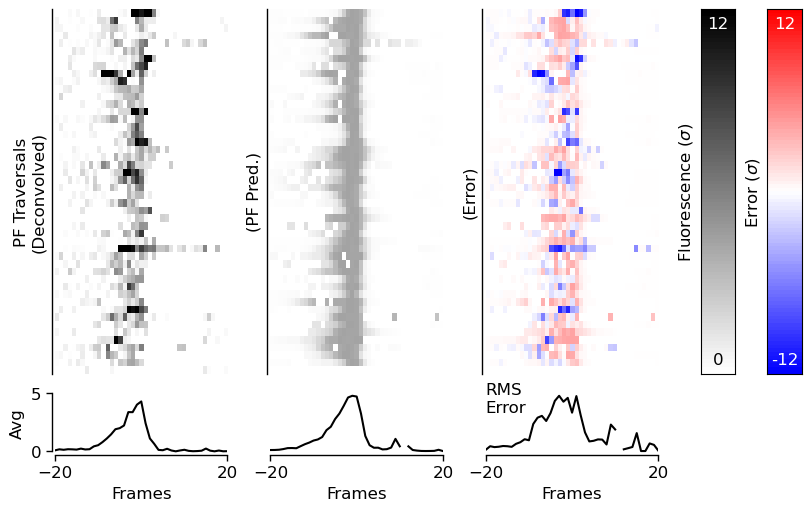

In [18]:
mouse_name = "ATL027"
date = "2023-07-27"
session_id = "701"
spks_type = "oasis"
session = B2Session.create(mouse_name, date, session_id, dict(spks_type=spks_type))

idx_roi = 96
idx_env = 0
fig = example_traversal(session, idx_roi, idx_env)

save_plot = False
if save_plot: 
    figure_name = f"example_trajectory_{mouse_name}_{date}_{session_id}_{spks_type}_{idx_roi}_{idx_env}"
    save_figure(fig, figure_path / f"{figure_name}.png")

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:695: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mask], axis=0)


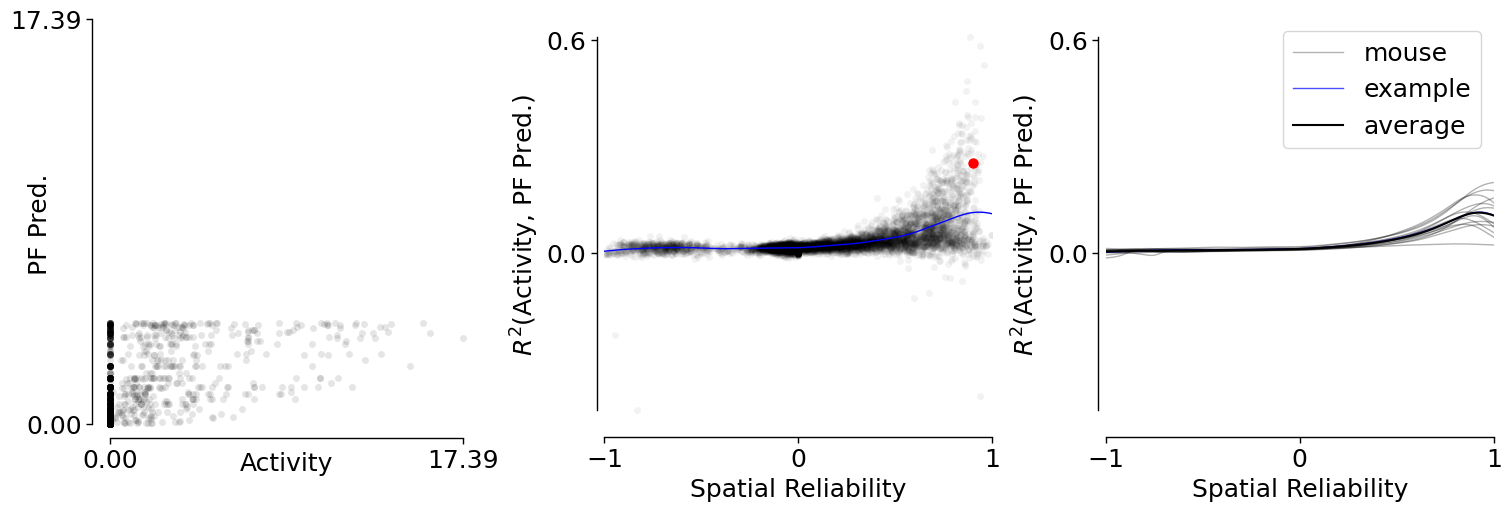

In [52]:
mouse_name = "ATL027"
date = "2023-07-27"
session_id = "701"
spks_type = "sigrebase"
idx_roi = {
    "oasis": 96,
    "sigrebase": 180,
}[spks_type]
session = B2Session.create(mouse_name, date, session_id, dict(spks_type=spks_type))

use_viewer = False
if use_viewer:
    viewer = example_r2_placefield(results, session, idx_roi, idx_env, return_syd_viewer=True)
    viewer.show()

else:
    fig = example_r2_placefield(results, session, idx_roi, idx_env, cloud_style="scatter", cloud_alpha=0.05, hex_count_norm="log")

    save_plot = True
    if save_plot: 
        figure_name = f"example_r2_placefield_{mouse_name}_{date}_{session_id}_{spks_type}_{idx_roi}_{idx_env}"
        save_figure(fig, figure_path / f"{figure_name}.png")